In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'
TEST_YEAR = '2025'
NUTS2_EL = 'θεσσαλιας'
MONTH = 'July'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(22666, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL61,EL611,καλαμπακας,2025,1,21.15549,39.67943,0.190868,0.580983,-0.086344,-0.580983,0.196631,0.634510,-0.021859,-0.634510,0.115345,0.093629,0.104714,0.093629,-1.433810,1.050645,-2.136667,9.162308,17.723333,-0.89000,-9.332667,-9.326154,0.745789,2.6300,-1.295625,-4.141011,-5.731410,4.954049,10.176667,-3.61,2.41,2.544667,0.25,0.82,76.339999,126.529998,11.000000,18.666667,43.410853,926.135666,37.0,-6.0,43.0,1.666667,18.166667,22.333333,-1.000000,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,30,30,10,10,1,6,6,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.0,2.204379,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3
1,1,EL61,EL611,καλαμπακας,2025,1,21.17860,39.62553,-0.079645,0.718312,0.236903,-0.718312,-0.044331,0.688008,0.280624,-0.688008,0.028200,0.064669,0.062054,0.064669,-1.770000,-0.011290,-2.787500,8.556154,10.942727,-0.15125,0.503333,-1.270000,1.600000,3.0812,-1.208125,0.246022,-2.028750,5.078077,7.011964,-5.81,2.61,2.544667,0.25,0.82,76.339999,126.529998,10.916667,17.166667,41.869919,864.668442,35.0,-6.0,41.0,3.333333,18.000000,21.666667,-0.166667,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,36,30,12,12,1,6,7,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.0,3.146997,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3
2,2,EL61,EL611,καλαμπακας,2025,1,21.17860,39.64350,0.253839,0.377498,-0.077630,-0.377498,0.175158,0.502486,0.015714,-0.502486,0.134806,0.139617,0.172246,0.139617,1.405000,1.010645,0.575000,11.792963,13.529091,-2.03400,0.478889,-1.709286,2.520968,4.2100,-0.314500,0.744767,-0.567143,7.156965,8.869545,-8.89,8.01,2.544667,0.25,0.82,76.339999,126.529998,11.833333,17.666667,40.151515,815.568216,36.0,-8.0,44.0,5.000000,18.166667,21.833333,1.666667,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,235.0,21,20,20,8,8,4,1,1,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.0,6.601146,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3
3,3,EL61,EL611,καλαμπακας,2025,1,21.17860,39.66147,-0.019601,0.737899,0.043780,-0.737899,-0.009302,0.714762,0.065505,-0.714762,0.047412,0.094558,0.094528,0.094558,-2.024545,-0.182258,-3.075833,7.455714,15.660000,-1.94680,-6.343333,-3.450000,1.270000,2.7724,-2.082273,-3.262796,-3.262917,4.362857,9.216200,-13.15,2.89,2.544667,0.25,0.82,76.339999,126.529998,10.083333,18.000000,36.734694,951.036118,36.0,-13.0,49.0,2.333333,17.166667,21.666667,-2.333333,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,36,30,12,12,1,6,7,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.0,1.083714,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3
4,4,EL61,EL611,καλαμπακας,2025,1,21.17860,39.67943,0.321370,0.269103,-0.231138,-0.269103,0.155505,0.433064,-0.087091,-0.433064,0.096466,0.146087,0.147036,0.146087,2.012857,2.492581,0.997500,10.558462,16.855455,-1.50600,-0.548519,-4.552500,0.645714,3.9828,0.070952,0.972031,-1.777500,5.602088,10.419127,-3.83,7.73,2.544667,

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

3238

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

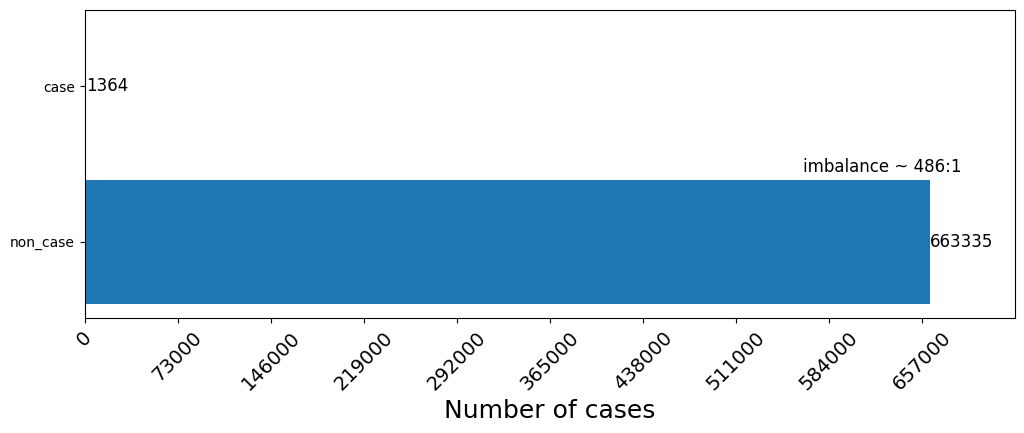

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

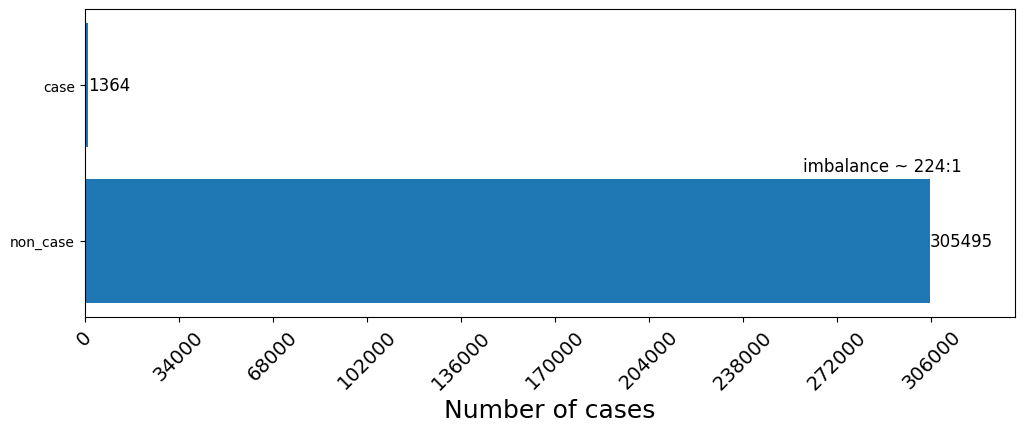

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

In [16]:
# data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# # dataset = dataset.query('month >= 5')
# data_train.reset_index(drop=True, inplace=True)

# plot_imbalance(data_train, target_column='cases')

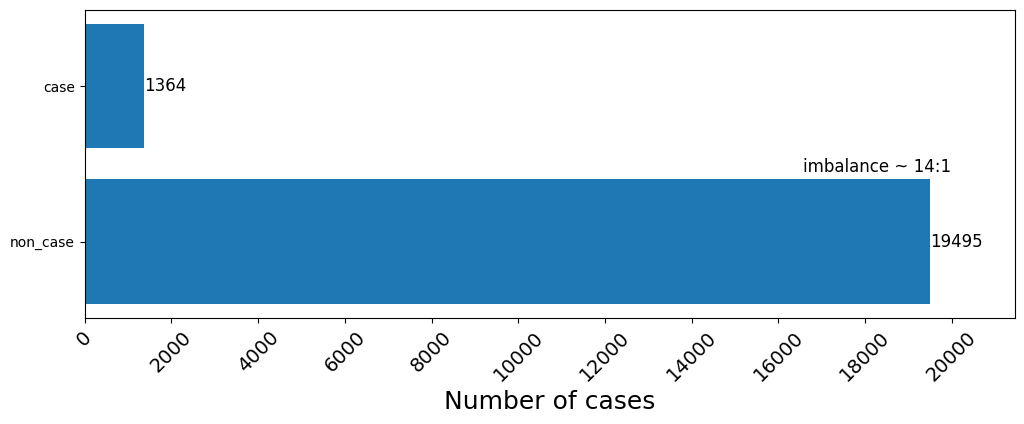

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(20720, 94)

In [19]:
data_train.cases.sum()

1364

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1651,262,1913,6.30%
1,2011,1605,100,1705,16.05%
2,2012,1615,157,1772,10.29%
3,2013,1658,85,1743,19.51%
4,2014,1556,15,1571,103.73%
5,2015,1647,0,1647,inf%
6,2016,1659,0,1659,inf%
7,2017,1588,42,1630,37.81%
8,2018,1570,296,1866,5.30%
9,2019,1651,218,1869,7.57%


In [21]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [22]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 14.29
Weight: 14.29


In [23]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
# data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
# data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
# data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [24]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL61,EL611,καλαμπακας,2025,5,21.15549,39.67943,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,1.050645,-2.136667,9.162308,17.723333,2.630000,-9.332667,-9.326154,0.745789,2.6300,10.283889,-4.141011,-5.731410,4.954049,10.176667,-1.23,21.15,1.931667,25.539999,30.269999,57.949999,454.289990,11.000000,18.666667,43.410853,926.135666,37.0,-6.0,43.0,1.666667,18.166667,22.333333,-1.000000,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,30,30,10,10,1,6,6,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3,0.5,-0.866025
1,1,EL61,EL611,καλαμπακας,2025,5,21.17860,39.62553,0.231700,0.044374,-0.229996,-0.044374,0.216594,0.116868,-0.152766,-0.116868,0.066685,0.064697,0.061938,0.064697,10.942727,-0.011290,-2.787500,8.556154,10.942727,3.081200,0.503333,-1.270000,1.600000,3.0812,7.115000,0.246022,-2.028750,5.078077,7.011964,-0.45,21.99,1.931667,25.539999,30.269999,57.949999,454.289990,10.916667,17.166667,41.869919,864.668442,35.0,-6.0,41.0,3.333333,18.000000,21.666667,-0.166667,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,36,30,12,12,1,6,7,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3,0.5,-0.866025
2,2,EL61,EL611,καλαμπακας,2025,5,21.17860,39.64350,0.411946,0.111530,-0.341385,-0.111530,0.437955,0.186996,-0.292635,-0.186996,0.084299,0.083744,0.057369,0.083744,13.529091,1.010645,0.575000,11.792963,13.529091,4.210000,0.478889,-1.709286,2.520968,4.2100,9.056364,0.744767,-0.567143,7.156965,8.869545,0.27,21.01,1.931667,25.539999,30.269999,57.949999,454.289990,11.833333,17.666667,40.151515,815.568216,36.0,-8.0,44.0,5.000000,18.166667,21.833333,1.666667,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,235.0,21,20,20,8,8,4,1,1,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3,0.5,-0.866025
3,3,EL61,EL611,καλαμπακας,2025,5,21.17860,39.66147,0.284429,-0.071878,-0.320869,0.071878,0.298423,0.081881,-0.250643,-0.081881,0.080327,0.097346,0.110010,0.097346,15.660000,-0.182258,-3.075833,7.455714,15.660000,2.772400,-6.343333,-3.450000,1.270000,2.7724,9.367727,-3.262796,-3.262917,4.362857,9.216200,-0.99,22.15,1.931667,25.539999,30.269999,57.949999,454.289990,10.083333,18.000000,36.734694,951.036118,36.0,-13.0,49.0,2.333333,17.166667,21.666667,-2.333333,850.0,159.0,0.0,81.616706,349.0,48.0,126.0,305.0,31,36,30,12,12,1,6,7,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.000000,1.083714,13833.0,67143.0,30134.0,111110.0,12916.0,64715.0,35063.0,112694.0,NaN,NaN,NaN,2,3,3,0.5,-0.866025
4,4,EL61,EL611,καλαμπακας,2025,5,21.17860,39.67943,0.513801,0.122665,-0.439457,-0.122665,0.479139,0.142633,-0.362511,-0.142633,0.070129,0.098426,0.076308,0.098426,16.855455,2.492581,0.9

### Results 2025 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
# X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
# X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
# X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3073,3073,EL61,EL613,βολου,2025,5,22.93488,39.37400,0.020413
2931,2931,EL61,EL613,ρηγα φερραιου,2025,5,22.81933,39.44587,0.015832
3004,3004,EL61,EL613,ρηγα φερραιου,2025,5,22.86555,39.48180,0.015681
2933,2933,EL61,EL613,ρηγα φερραιου,2025,5,22.81933,39.48180,0.012227
2757,2757,EL61,EL612,κιλελερ,2025,5,22.72690,39.53570,0.010644


In [32]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
776,776,EL61,EL611,τρικκαιων,2025,6,21.77943,39.55367,0.509975
3088,3088,EL61,EL613,βολου,2025,6,22.95799,39.37400,0.450009
1462,1462,EL61,EL611,σοφαδων,2025,6,22.12606,39.23027,0.444917
3073,3073,EL61,EL613,βολου,2025,6,22.93488,39.37400,0.374528
3056,3056,EL61,EL613,βολου,2025,6,22.91177,39.39197,0.373602


In [33]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2958,2958,EL61,EL613,αλμυρου,2025,7,22.84244,39.14043,0.919477
2802,2802,EL61,EL612,κιλελερ,2025,7,22.75000,39.49977,0.909787
3073,3073,EL61,EL613,βολου,2025,7,22.93488,39.37400,0.908722
3004,3004,EL61,EL613,ρηγα φερραιου,2025,7,22.86555,39.48180,0.908116
776,776,EL61,EL611,τρικκαιων,2025,7,21.77943,39.55367,0.908112


In [34]:
# results_aug.sort_values(by='score', ascending=False).head(5)

In [35]:
# results_sep.sort_values(by='score', ascending=False).head(5)

In [36]:
# results_oct.sort_values(by='score', ascending=False).head(5)

In [37]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [38]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [39]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."


In [40]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL61,Θεσσαλία,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [41]:
greece_lau1.head()

,NAME,geometry
0,Αγιάς,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αλοννήσου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
2,Αλμυρού,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
3,Αργιθέας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
4,Βόλου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [42]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,SMOKOVO RESERVOIR,9917521.0,57610.200,"POLYGON ((22.15620 39.12133, 22.15606 39.12153...",0
1,KARLAS RESERVOIR,34925588.0,29704.895,"POLYGON ((22.78083 39.49649, 22.78114 39.49670...",1
2,TAVROPOS RESERVOIR,23560746.0,85317.960,"POLYGON ((21.69880 39.34183, 21.69943 39.34191...",2


In [43]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
results_jul['x'] = results_jul['x'].round(4)
results_jul['y'] = results_jul['y'].round(4)
results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
results_jul['risk_score'] = results_jul['risk_score'].round(6)

# results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
# results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
# results_aug['x'] = results_aug['x'].round(4)
# results_aug['y'] = results_aug['y'].round(4)
# results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
# results_aug['risk_score'] = results_aug['risk_score'].round(6)

# results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
# results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
# results_sep['x'] = results_sep['x'].round(4)
# results_sep['y'] = results_sep['y'].round(4)
# results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
# results_sep['risk_score'] = results_sep['risk_score'].round(6)

# results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
# results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
# results_oct['x'] = results_oct['x'].round(4)
# results_oct['y'] = results_oct['y'].round(4)
# results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
# results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [44]:
type(results_may)

geopandas.geodataframe.GeoDataFrame

In [45]:
# results_may.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

results_jul.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

# results_aug.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [46]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

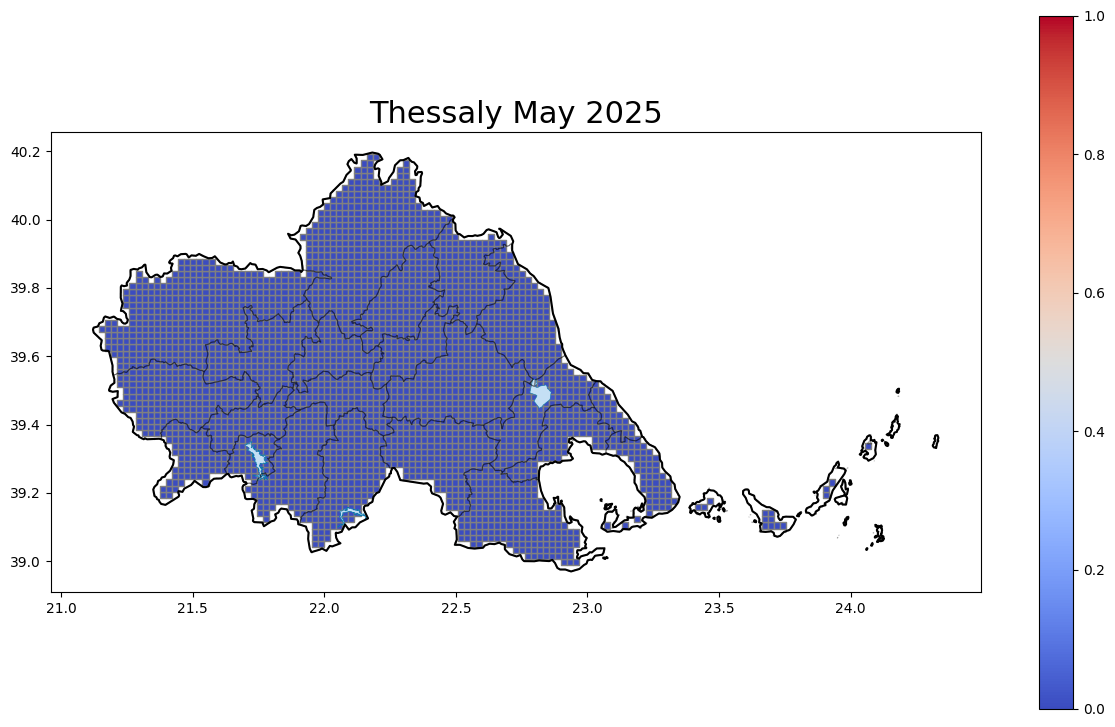

In [47]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

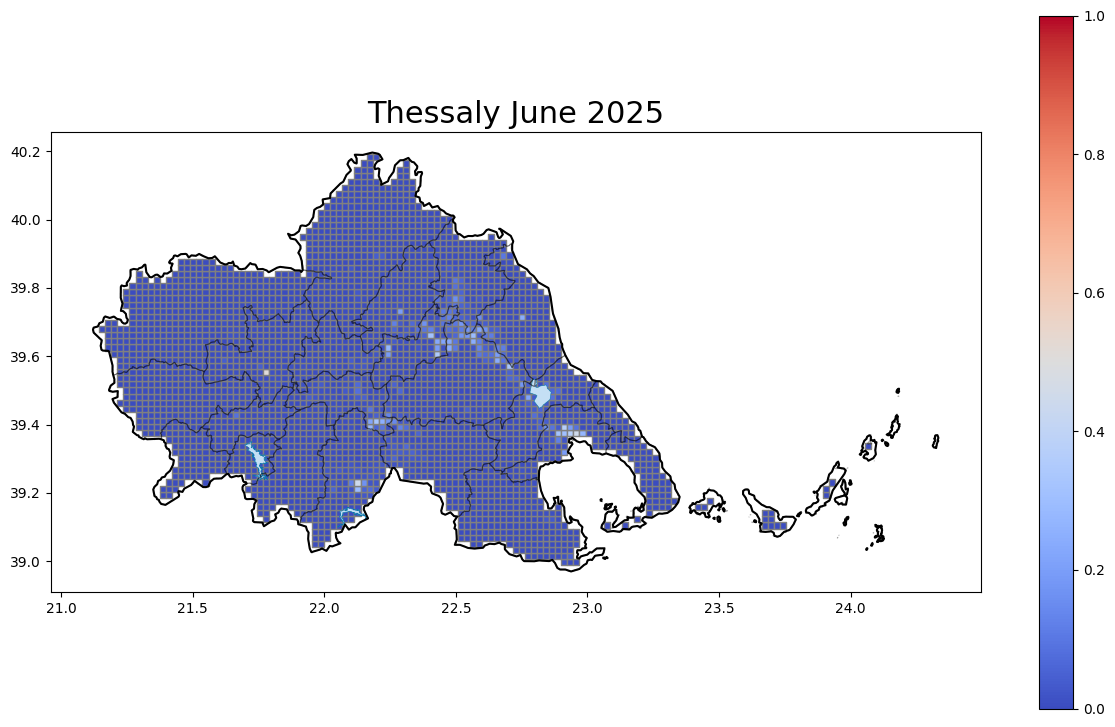

In [48]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

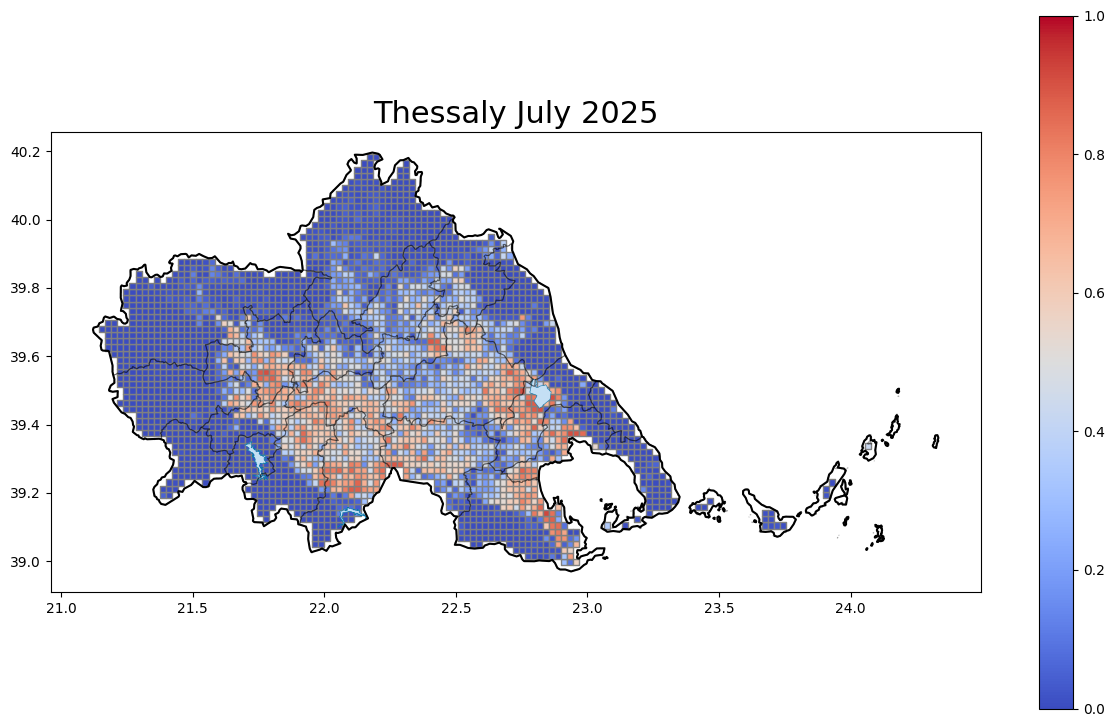

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [50]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [51]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [52]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [53]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_may, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


# ==================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [54]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jun, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

# ==================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [55]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jul, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, size_f5=6.5)

# fig.show()

# ==================================================================================================================================================

# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [56]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


# ==================================================================================================================================================

# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [57]:
results_may

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL61,EL611,καλαμπακας,2025,5,21.1555,39.6794,0.000030,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,EL61,EL611,καλαμπακας,2025,5,21.1786,39.6255,0.000013,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,EL61,EL611,καλαμπακας,2025,5,21.1786,39.6435,0.000022,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,EL61,EL611,καλαμπακας,2025,5,21.1786,39.6615,0.000037,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,EL61,EL611,καλαμπακας,2025,5,21.1786,39.6794,0.000025,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."
...,...,...,...,...,...,...,...,...,...,...
3233,3233,EL61,EL613,σκοπελου,2025,5,23.7437,39.1045,0.000076,"POLYGON ((23.75524 39.09551, 23.73213 39.09551..."
3234,3234,EL61,EL613,αλοννησου,2025,5,23.9054,39.1943,0.000244,"POLYGON ((23.91701 39.18535, 23.89390 39.18535..."
3235,3235,EL61,EL613,αλοννησου,2025,5,23.9054,39.2123,0.000179,"POLYGON ((23.91701 39.20331, 23.89390 39.20331..."
3236,3236,EL61,EL613,αλοννησου,2025,5,23.9286,39.2303,0.000040,"POLYGON ((23.94012 39.22128, 23.91701 39.22128..."


In [58]:
results_may_to_send = results_may[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_may_to_send['cell_id'] = results_may_to_send['nuts3_id'] + '-' + results_may_to_send['cell_number'].astype(str).str.zfill(4)
results_may_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_may_to_send['lau1'] = results_may_to_send['lau1'].str.upper()
results_may_to_send = results_may_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_may_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_may_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL611-0000,ΚΑΛΑΜΠΑΚΑΣ,5,2025,21.1555,39.6794,0.000030
1,EL611-0001,ΚΑΛΑΜΠΑΚΑΣ,5,2025,21.1786,39.6255,0.000013
2,EL611-0002,ΚΑΛΑΜΠΑΚΑΣ,5,2025,21.1786,39.6435,0.000022
3,EL611-0003,ΚΑΛΑΜΠΑΚΑΣ,5,2025,21.1786,39.6615,0.000037
4,EL611-0004,ΚΑΛΑΜΠΑΚΑΣ,5,2025,21.1786,39.6794,0.000025
...,...,...,...,...,...,...,...
3233,EL613-3233,ΣΚΟΠΕΛΟΥ,5,2025,23.7437,39.1045,0.000076
3234,EL613-3234,ΑΛΟΝΝΗΣΟΥ,5,2025,23.9054,39.1943,0.000244
3235,EL613-3235,ΑΛΟΝΝΗΣΟΥ,5,2025,23.9054,39.2123,0.000179
3236,EL613-3236,ΑΛΟΝΝΗΣΟΥ,5,2025,23.9286,39.2303,0.000040


In [58]:
results_jun

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL61,EL611,καλαμπακας,2025,6,21.1555,39.6794,0.000024,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,EL61,EL611,καλαμπακας,2025,6,21.1786,39.6255,0.000009,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,EL61,EL611,καλαμπακας,2025,6,21.1786,39.6435,0.000006,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,EL61,EL611,καλαμπακας,2025,6,21.1786,39.6615,0.000009,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,EL61,EL611,καλαμπακας,2025,6,21.1786,39.6794,0.000013,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."
...,...,...,...,...,...,...,...,...,...,...
3233,3233,EL61,EL613,σκοπελου,2025,6,23.7437,39.1045,0.000131,"POLYGON ((23.75524 39.09551, 23.73213 39.09551..."
3234,3234,EL61,EL613,αλοννησου,2025,6,23.9054,39.1943,0.000218,"POLYGON ((23.91701 39.18535, 23.89390 39.18535..."
3235,3235,EL61,EL613,αλοννησου,2025,6,23.9054,39.2123,0.000293,"POLYGON ((23.91701 39.20331, 23.89390 39.20331..."
3236,3236,EL61,EL613,αλοννησου,2025,6,23.9286,39.2303,0.000132,"POLYGON ((23.94012 39.22128, 23.91701 39.22128..."


In [60]:
results_jun_to_send = results_jun[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_jun_to_send['cell_id'] = results_jun_to_send['nuts3_id'] + '-' + results_jun_to_send['cell_number'].astype(str).str.zfill(4)
results_jun_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_jun_to_send['lau1'] = results_jun_to_send['lau1'].str.upper()
results_jun_to_send = results_jun_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_jun_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jun_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_jun_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL611-0000,ΚΑΛΑΜΠΑΚΑΣ,6,2025,21.1555,39.6794,0.000024
1,EL611-0001,ΚΑΛΑΜΠΑΚΑΣ,6,2025,21.1786,39.6255,0.000009
2,EL611-0002,ΚΑΛΑΜΠΑΚΑΣ,6,2025,21.1786,39.6435,0.000006
3,EL611-0003,ΚΑΛΑΜΠΑΚΑΣ,6,2025,21.1786,39.6615,0.000009
4,EL611-0004,ΚΑΛΑΜΠΑΚΑΣ,6,2025,21.1786,39.6794,0.000013
...,...,...,...,...,...,...,...
3233,EL613-3233,ΣΚΟΠΕΛΟΥ,6,2025,23.7437,39.1045,0.000131
3234,EL613-3234,ΑΛΟΝΝΗΣΟΥ,6,2025,23.9054,39.1943,0.000218
3235,EL613-3235,ΑΛΟΝΝΗΣΟΥ,6,2025,23.9054,39.2123,0.000293
3236,EL613-3236,ΑΛΟΝΝΗΣΟΥ,6,2025,23.9286,39.2303,0.000132


In [59]:
results_jul

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL61,EL611,καλαμπακας,2025,7,21.1555,39.6794,0.000253,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,EL61,EL611,καλαμπακας,2025,7,21.1786,39.6255,0.000147,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,EL61,EL611,καλαμπακας,2025,7,21.1786,39.6435,0.000019,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,EL61,EL611,καλαμπακας,2025,7,21.1786,39.6615,0.000185,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,EL61,EL611,καλαμπακας,2025,7,21.1786,39.6794,0.000194,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."
...,...,...,...,...,...,...,...,...,...,...
3233,3233,EL61,EL613,σκοπελου,2025,7,23.7437,39.1045,0.005028,"POLYGON ((23.75524 39.09551, 23.73213 39.09551..."
3234,3234,EL61,EL613,αλοννησου,2025,7,23.9054,39.1943,0.022908,"POLYGON ((23.91701 39.18535, 23.89390 39.18535..."
3235,3235,EL61,EL613,αλοννησου,2025,7,23.9054,39.2123,0.014815,"POLYGON ((23.91701 39.20331, 23.89390 39.20331..."
3236,3236,EL61,EL613,αλοννησου,2025,7,23.9286,39.2303,0.005323,"POLYGON ((23.94012 39.22128, 23.91701 39.22128..."


In [60]:
results_jul_to_send = results_jul[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_jul_to_send['cell_id'] = results_jul_to_send['nuts3_id'] + '-' + results_jul_to_send['cell_number'].astype(str).str.zfill(4)
results_jul_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_jul_to_send['lau1'] = results_jul_to_send['lau1'].str.upper()
results_jul_to_send = results_jul_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_jul_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jul_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_jul_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL611-0000,ΚΑΛΑΜΠΑΚΑΣ,7,2025,21.1555,39.6794,0.000253
1,EL611-0001,ΚΑΛΑΜΠΑΚΑΣ,7,2025,21.1786,39.6255,0.000147
2,EL611-0002,ΚΑΛΑΜΠΑΚΑΣ,7,2025,21.1786,39.6435,0.000019
3,EL611-0003,ΚΑΛΑΜΠΑΚΑΣ,7,2025,21.1786,39.6615,0.000185
4,EL611-0004,ΚΑΛΑΜΠΑΚΑΣ,7,2025,21.1786,39.6794,0.000194
...,...,...,...,...,...,...,...
3233,EL613-3233,ΣΚΟΠΕΛΟΥ,7,2025,23.7437,39.1045,0.005028
3234,EL613-3234,ΑΛΟΝΝΗΣΟΥ,7,2025,23.9054,39.1943,0.022908
3235,EL613-3235,ΑΛΟΝΝΗΣΟΥ,7,2025,23.9054,39.2123,0.014815
3236,EL613-3236,ΑΛΟΝΝΗΣΟΥ,7,2025,23.9286,39.2303,0.005323
